<a href="https://colab.research.google.com/github/jessicasalazar/vision_computador/blob/main/Taller_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Workshop # 4

* Implement a CNN or ViT model. It can be a model from a library (Keras) or a “vanilla” implementation of a CNN.
* Invent a pretext task
* Train on ImageNe


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers as L

# limpiar memoria GPU al usar TensorFlow
tf.keras.backend.clear_session()

In [ ]:
# Configuration
IMG_SIZE = 160  # size to resize
BATCH    = 128
EPOCHS_FROZEN   = 25    # Aumentado de 15 a 25
EPOCHS_UNFROZEN = 10    # Aumentado de 6 a 10
LR_FROZEN   = 3e-4
LR_UNFROZEN = 5e-5      # Más bajo para fine-tuning más cuidadoso
SEED     = 1337
AUTOTUNE = tf.data.AUTOTUNE

tf.random.set_seed(SEED)

In [ ]:
# Dataset load (CIFAR-10)
(x_train, _), (x_val, _) = tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step


In [ ]:
# Preprocess
def preprocess(x, y):
    x = tf.cast(x, tf.float32)
    # CIFAR-10 is already RGB (32x32x3), just resize and normalize
    x = tf.image.resize(x, (IMG_SIZE, IMG_SIZE))
    # Normalize for MobileNetV2 (ImageNet preprocessing)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
    return x, y

def preprocess_with_augmentation(x, y):
    """Preprocesamiento con data augmentation para entrenamiento"""
    x = tf.cast(x, tf.float32)
    # Data Augmentation
    x = tf.image.random_flip_left_right(x)
    x = tf.image.random_brightness(x, max_delta=0.1)
    x = tf.image.random_contrast(x, lower=0.9, upper=1.1)
    x = tf.clip_by_value(x, 0, 255)
    # Resize and normalize
    x = tf.image.resize(x, (IMG_SIZE, IMG_SIZE))
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
    return x, y

def add_rotnet_label(x, _):
    k = tf.random.uniform((), 0, 4, dtype=tf.int32) # pretext task is random rotation k∈{0,1,2,3}
    x = tf.image.rot90(x, k)
    y = k  # the label is the discretized angle (0,1,2,3)
    return x, y

In [ ]:
# Pipelines tf.data
ds_train = tf.data.Dataset.from_tensor_slices((x_train, tf.zeros((x_train.shape[0],))))
ds_train = ds_train.shuffle(50000, seed=SEED)
ds_train = ds_train.map(preprocess_with_augmentation, num_parallel_calls=AUTOTUNE)  # Con augmentation
ds_train = ds_train.map(add_rotnet_label, num_parallel_calls=AUTOTUNE)
ds_train = ds_train.batch(BATCH).prefetch(AUTOTUNE)

ds_val = tf.data.Dataset.from_tensor_slices((x_val, tf.zeros((x_val.shape[0],))))
ds_val = ds_val.map(preprocess, num_parallel_calls=AUTOTUNE)  # Sin augmentation
ds_val = ds_val.map(add_rotnet_label, num_parallel_calls=AUTOTUNE)
ds_val = ds_val.batch(BATCH).prefetch(AUTOTUNE)

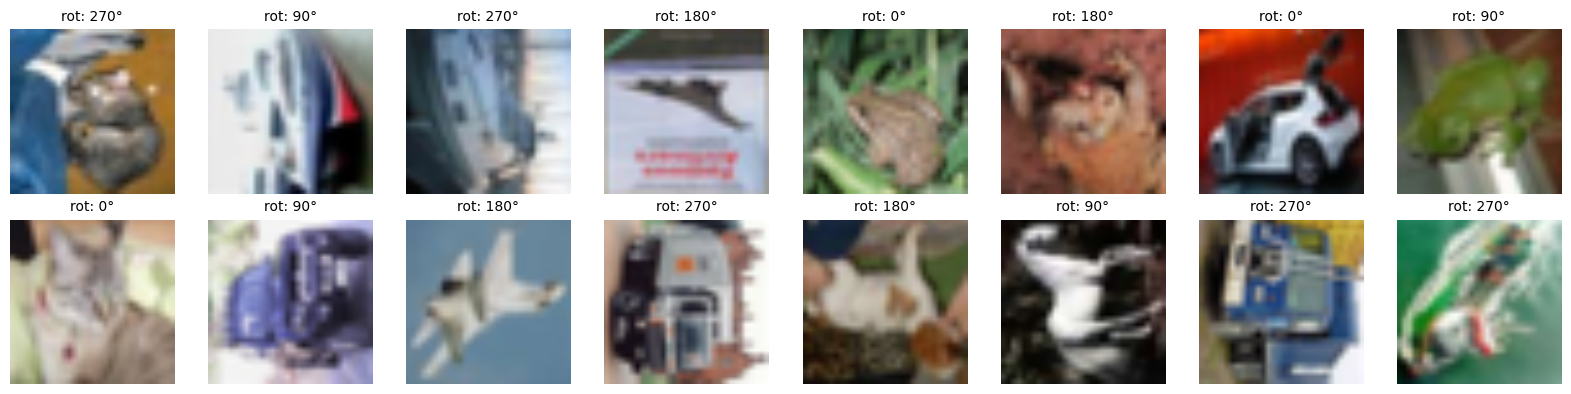

In [ ]:
# Visualizations of images with label and rotation angle
import matplotlib.pyplot as plt
import numpy as np

N = 16
COLS = 8
DEG = ['0°','90°','180°','270°']

# We use a batch of validation dataset
for batch_imgs, batch_labels in ds_val.take(1):
    imgs = batch_imgs.numpy()
    labels = batch_labels.numpy()

    # Reverse MobileNetV2 preprocessing: [-1,1] -> [0,1]
    imgs = (imgs + 1.0) / 2.0
    imgs = np.clip(imgs, 0, 1)

    # We set up the grid.
    rows = (N + COLS - 1) // COLS
    plt.figure(figsize=(COLS * 2, rows * 2))

    for i in range(N):
        if i >= len(imgs):
            break
        plt.subplot(rows, COLS, i + 1)
        plt.imshow(imgs[i])
        plt.title(f"rot: {DEG[int(labels[i])]}",
                  fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
# Model: MobileNetV2 (ImageNet) + cabeza RotNet mejorada
inp = L.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
base = tf.keras.applications.MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    pooling='avg'
)
base.trainable = False
x = base(inp, training=False)
# Cabeza más profunda con BatchNormalization
x = L.Dense(256, activation='relu', name='dense1')(x)
x = L.BatchNormalization()(x)
x = L.Dropout(0.3)(x)
x = L.Dense(128, activation='relu', name='dense2')(x)
x = L.BatchNormalization()(x)
x = L.Dropout(0.3)(x)
out = L.Dense(4, activation='softmax', name='output')(x)
model = tf.keras.Model(inp, out)

print(f"Parámetros del modelo: {model.count_params():,}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Parámetros del modelo: 2,620,868


In [ ]:
# Compilation (phase 1: frozen base)
model.compile(optimizer=tf.keras.optimizers.Adam(LR_FROZEN),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [ ]:
# Callbacks para mejor entrenamiento
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

# Reduce learning rate cuando la val_loss se estanque
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

# Para early stopping si no mejora
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Guardar mejor modelo
checkpoint = ModelCheckpoint(
    'best_rotnet_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

callbacks_list = [reduce_lr, early_stop, checkpoint]

In [ ]:
# Training (phase 1)
history = model.fit(ds_train,
                    validation_data=ds_val,
                    epochs=EPOCHS_FROZEN,
                    callbacks=callbacks_list,
                    verbose=1)

Epoch 1/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.4448 - loss: 1.4379
Epoch 1: val_accuracy improved from -inf to 0.54750, saving model to best_rotnet_model.h5


391/391 ━━━━━━━━━━━━━━━━━━━━ 82s 156ms/step - accuracy: 0.4449 - loss: 1.4374 - val_accuracy: 0.5475 - val_loss: 0.9463 - learning_rate: 3.0000e-04
Epoch 2/25
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.5407 - loss: 1.0087
Epoch 2: val_accuracy improved from 0.54750 to 0.57090, saving model to best_rotnet_model.h5


391/391 ━━━━━━━━━━━━━━━━━━━━ 35s 89ms/step - accuracy: 0.5408 - loss: 1.0086 - val_accuracy: 0.5709 - val_loss: 0.8691 - learning_rate: 3.0000e-04
Epoch 3/25
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.5614 - loss: 0.9311
Epoch 3: val_accuracy improved from 0.57090 to 0.58110, saving model to best_rotnet_model.h5


391/391 ━━━━━━━━━━━━━━━━━━━━ 34s 87ms/step - accuracy: 0.5614 - loss: 0.9311 - val_accuracy: 0.5811 - val_loss: 0.8517 - learning_rate: 3.0000e-04
Epoch 4/25
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.5744 - loss: 0.8858
Epoch 4: val_accuracy improved from 0.58110 to 0.59210, saving model to best_rotnet_model.h5


391/391 ━━━━━━━━━━━━━━━━━━━━ 34s 87ms/step - accuracy: 0.5744 - loss: 0.8858 - val_accuracy: 0.5921 - val_loss: 0.8382 - learning_rate: 3.0000e-04
Epoch 5/25
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.5806 - loss: 0.8677
Epoch 5: val_accuracy did not improve from 0.59210
391/391 ━━━━━━━━━━━━━━━━━━━━ 33s 84ms/step - accuracy: 0.5806 - loss: 0.8677 - val_accuracy: 0.5918 - val_loss: 0.8298 - learning_rate: 3.0000e-04
Epoch 6/25
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.5855 - loss: 0.8475
Epoch 6: val_accuracy improved from 0.59210 to 0.60550, saving model to best_rotnet_model.h5


...

391/391 ━━━━━━━━━━━━━━━━━━━━ 34s 86ms/step - accuracy: 0.6245 - loss: 0.7677 - val_accuracy: 0.6303 - val_loss: 0.7514 - learning_rate: 3.0000e-04
Epoch 19/25
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.6346 - loss: 0.7582
Epoch 19: val_accuracy did not improve from 0.63030
391/391 ━━━━━━━━━━━━━━━━━━━━ 35s 89ms/step - accuracy: 0.6346 - loss: 0.7582 - val_accuracy: 0.6284 - val_loss: 0.7592 - learning_rate: 3.0000e-04
Epoch 20/25
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.6349 - loss: 0.7509
Epoch 20: val_accuracy improved from 0.63030 to 0.63150, saving model to best_rotnet_model.h5


391/391 ━━━━━━━━━━━━━━━━━━━━ 35s 89ms/step - accuracy: 0.6349 - loss: 0.7510 - val_accuracy: 0.6315 - val_loss: 0.7574 - learning_rate: 3.0000e-04
Epoch 21/25
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.6350 - loss: 0.7498
Epoch 21: val_accuracy improved from 0.63150 to 0.63320, saving model to best_rotnet_model.h5


391/391 ━━━━━━━━━━━━━━━━━━━━ 35s 88ms/step - accuracy: 0.6350 - loss: 0.7498 - val_accuracy: 0.6332 - val_loss: 0.7457 - learning_rate: 3.0000e-04
Epoch 22/25
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.6369 - loss: 0.7482
Epoch 22: val_accuracy did not improve from 0.63320
391/391 ━━━━━━━━━━━━━━━━━━━━ 33s 84ms/step - accuracy: 0.6369 - loss: 0.7482 - val_accuracy: 0.6308 - val_loss: 0.7563 - learning_rate: 3.0000e-04
Epoch 23/25
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.6360 - loss: 0.7432
Epoch 23: val_accuracy did not improve from 0.63320
391/391 ━━━━━━━━━━━━━━━━━━━━ 34s 87ms/step - accuracy: 0.6360 - loss: 0.7432 - val_accuracy: 0.6207 - val_loss: 0.7811 - learning_rate: 3.0000e-04
Epoch 24/25
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.6376 - loss: 0.7416
Epoch 24: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.

Epoch 24: val_accuracy improved from 0.63320 to 0.63420, saving model to best_rotnet_model.h5


391/391 ━━━━━━━━━━━━━━━━━━━━ 35s 89ms/step - accuracy: 0.6376 - loss: 0.7416 - val_accuracy: 0.6342 - val_loss: 0.7568 - learning_rate: 3.0000e-04
Epoch 25/25
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.6427 - loss: 0.7391
Epoch 25: val_accuracy improved from 0.63420 to 0.63870, saving model to best_rotnet_model.h5


391/391 ━━━━━━━━━━━━━━━━━━━━ 34s 87ms/step - accuracy: 0.6427 - loss: 0.7391 - val_accuracy: 0.6387 - val_loss: 0.7355 - learning_rate: 1.5000e-04
Restoring model weights from the end of the best epoch: 25.


In [ ]:
# Fine-tuning: Unfreeze the final part of the base
base.trainable = True
n_total = len(base.layers)
freeze_until = n_total - 40
for i, layer in enumerate(base.layers):
    layer.trainable = (i >= freeze_until)

In [ ]:
# Recompile with a lower learning rate.
model.compile(optimizer=tf.keras.optimizers.Adam(LR_UNFROZEN),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Training (phase 2: fine-tuning)
history_ft = model.fit(ds_train,
                       validation_data=ds_val,
                       epochs=EPOCHS_UNFROZEN,
                       callbacks=callbacks_list,
                       verbose=1)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.5923 - loss: 0.8657
Epoch 1: val_accuracy did not improve from 0.63870
391/391 ━━━━━━━━━━━━━━━━━━━━ 75s 137ms/step - accuracy: 0.5924 - loss: 0.8655 - val_accuracy: 0.6201 - val_loss: 0.8650 - learning_rate: 5.0000e-05
Epoch 2/10
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.6848 - loss: 0.6903
Epoch 2: val_accuracy improved from 0.63870 to 0.67870, saving model to best_rotnet_model.h5


391/391 ━━━━━━━━━━━━━━━━━━━━ 36s 93ms/step - accuracy: 0.6849 - loss: 0.6902 - val_accuracy: 0.6787 - val_loss: 0.6859 - learning_rate: 5.0000e-05
Epoch 3/10
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.7510 - loss: 0.5914
Epoch 3: val_accuracy improved from 0.67870 to 0.74480, saving model to best_rotnet_model.h5


391/391 ━━━━━━━━━━━━━━━━━━━━ 40s 91ms/step - accuracy: 0.7510 - loss: 0.5913 - val_accuracy: 0.7448 - val_loss: 0.5841 - learning_rate: 5.0000e-05
Epoch 4/10
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.7954 - loss: 0.5063
Epoch 4: val_accuracy improved from 0.74480 to 0.77990, saving model to best_rotnet_model.h5


391/391 ━━━━━━━━━━━━━━━━━━━━ 36s 91ms/step - accuracy: 0.7954 - loss: 0.5062 - val_accuracy: 0.7799 - val_loss: 0.5458 - learning_rate: 5.0000e-05
Epoch 5/10
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.8202 - loss: 0.4540
Epoch 5: val_accuracy improved from 0.77990 to 0.81680, saving model to best_rotnet_model.h5


391/391 ━━━━━━━━━━━━━━━━━━━━ 46s 105ms/step - accuracy: 0.8202 - loss: 0.4540 - val_accuracy: 0.8168 - val_loss: 0.4634 - learning_rate: 5.0000e-05
Epoch 6/10
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.8370 - loss: 0.4181
Epoch 6: val_accuracy did not improve from 0.81680
391/391 ━━━━━━━━━━━━━━━━━━━━ 36s 91ms/step - accuracy: 0.8370 - loss: 0.4181 - val_accuracy: 0.8168 - val_loss: 0.4676 - learning_rate: 5.0000e-05
Epoch 7/10
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.8518 - loss: 0.3812
Epoch 7: val_accuracy improved from 0.81680 to 0.83510, saving model to best_rotnet_model.h5


391/391 ━━━━━━━━━━━━━━━━━━━━ 42s 93ms/step - accuracy: 0.8518 - loss: 0.3812 - val_accuracy: 0.8351 - val_loss: 0.4329 - learning_rate: 5.0000e-05
Epoch 8/10
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.8602 - loss: 0.3661
Epoch 8: val_accuracy improved from 0.83510 to 0.84300, saving model to best_rotnet_model.h5


391/391 ━━━━━━━━━━━━━━━━━━━━ 36s 92ms/step - accuracy: 0.8602 - loss: 0.3661 - val_accuracy: 0.8430 - val_loss: 0.4061 - learning_rate: 5.0000e-05
Epoch 9/10
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.8693 - loss: 0.3478
Epoch 9: val_accuracy did not improve from 0.84300
391/391 ━━━━━━━━━━━━━━━━━━━━ 42s 106ms/step - accuracy: 0.8693 - loss: 0.3478 - val_accuracy: 0.8340 - val_loss: 0.4271 - learning_rate: 5.0000e-05
Epoch 10/10
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.8783 - loss: 0.3253
Epoch 10: val_accuracy did not improve from 0.84300
391/391 ━━━━━━━━━━━━━━━━━━━━ 46s 117ms/step - accuracy: 0.8783 - loss: 0.3253 - val_accuracy: 0.8425 - val_loss: 0.4331 - learning_rate: 5.0000e-05
Restoring model weights from the end of the best epoch: 8.


In [ ]:
# Evaluation
model = tf.keras.models.load_model('best_rotnet_model.h5')
val_loss, val_acc = model.evaluate(ds_val, verbose=0)
print(f"Accuracy de rotación (val): {val_acc:.4f}")

Accuracy de rotación (val): 0.8442


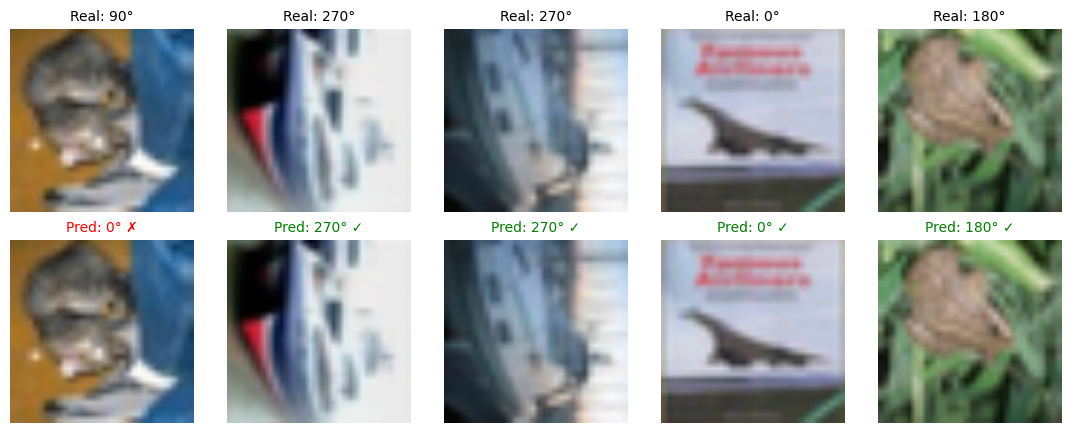

Guardado 'rotnet_5_pares.png'


<Figure size 640x480 with 0 Axes>

In [ ]:
# Show 5 pairs: (row 1) REAL label, (row 2) PREDICTED label.

import numpy as np
import matplotlib.pyplot as plt

DEG = ['0°','90°','180°','270°']
N = 5

# Batch to validation dataset
for batch_imgs, batch_labels in ds_val.take(1):
    imgs_tf = batch_imgs[:N]
    labels_tf = batch_labels[:N]

    logits = model.predict(imgs_tf, verbose=0)
    preds = np.argmax(logits, axis=1)

    # Tensor to numpy
    imgs = imgs_tf.numpy()
    # Reverse MobileNetV2 preprocessing: [-1,1] -> [0,1]
    imgs = (imgs + 1.0) / 2.0
    imgs = np.clip(imgs, 0, 1)
    reals = labels_tf.numpy().astype(int)

    # We prepare a figure with 2 rows (real/pred) and N columns (N pairs).
    plt.figure(figsize=(N * 2.2, 2 * 2.2))

    for i in range(N):
        plt.subplot(2, N, i + 1)
        plt.imshow(imgs[i])
        plt.title(f"Real: {DEG[int(reals[i])]}",
                  fontsize=10)
        plt.axis('off')

    # PREDICTED
    for i in range(N):
        plt.subplot(2, N, N + i + 1)
        plt.imshow(imgs[i])
        ok = (preds[i] == reals[i])
        suf = "✓" if ok else "✗"
        color = 'green' if ok else 'red'
        plt.title(f"Pred: {DEG[int(preds[i])]} {suf}", fontsize=10, color=color)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

    # Save
    plt.savefig("rotnet_5_pares.png", dpi=150)
    print("Guardado 'rotnet_5_pares.png'")




